In [1]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 11
Total threads: 11,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:59302,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:59334,Total threads: 1
Dashboard: http://127.0.0.1:59338/status,Memory: 1.64 GiB
Nanny: tcp://127.0.0.1:59305,


In [2]:
"""
This cell just opens a netcdf which is sitting in my users object storage on Pawsey.
Mostly intended as a demo that the dataset actually exists, and has the right settings
to be openeed by an anonymous user.
"""
import xarray as xr

url = "s3://zarr-data-stream-test/output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/tasmax/tasmax_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_201001-201012.nc"

ds = xr.open_dataset(
    url,
    engine="h5netcdf",
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
    chunks={},
    decode_times=False,
)

# This is just straight up opening the dataset on Pawsy
# ds['sst_m'].isel(time=0).plot()
ds

<xarray.Dataset> Size: 7MB
Dimensions:       (time: 12, rlat: 279, rlon: 364, rot_pole: 1, bnds: 2)
Coordinates:
  * time          (time) float64 96B 2.196e+04 2.199e+04 ... 2.226e+04 2.23e+04
  * rlat          (rlat) float64 2kB -11.34 -11.31 -11.27 ... -1.592 -1.557
  * rlon          (rlon) float64 3kB 147.7 147.7 147.7 ... 160.4 160.4 160.4
    lat           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    lon           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    rotated_pole  (rot_pole) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, bnds) float64 192B dask.array<chunksize=(12, 2), meta=np.ndarray>
    height        float64 8B ...
Dimensions without coordinates: rot_pole, bnds
Data variables:
    tasmax        (time, rlat, rlon) float32 5MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
Attributes: (12/28)
    institute_id:                   WA-DWER
    institution:                    Murdoch University and Department of Wate...
    contact:                        Jatin Kala (J.Kala@murdoch.edu.au), Sean ...
    references:                     https://www.wa.gov.au/organisation/depart...
    project_id:                     WA-CSI
    product:                        output
    ...                             ...
    wrf_shemes_ra_lw_physics:       Iacono, M. J., J. S. Delamere, E. J. Mlaw...
    wrf_shemes_sf_sfclay_physics:   Revised_MM5; Jimenez et al. (2012, MWR)
    wrf_shemes_sf_surface_physics:  Niu, Guo-Yue, Zong-Liang Yang, Kenneth E....
    wrf_shemes_mp_physics:          Thompson, Gregory, Paul R. Field, Roy M. ...
    wrf_shemes_bl_pbl_physics:      Nakanishi, M., and H. Niino, 2006: An imp...
    wrf_shemes_cu_physics:          Disabled

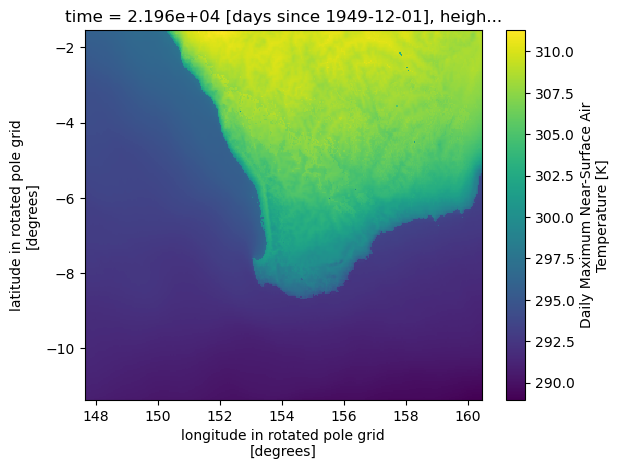

In [3]:
ds['tasmax'].isel(time=0).plot()

In [2]:
import os
import xarray as xr
from obstore.store import S3Store

from dotenv import load_dotenv

load_dotenv()

access_key_id = os.environ.get("ATMOS_ACCESS_KEY_ID")
secret_access_key = os.environ.get("ATMOS_SECRET_ACCESS_KEY")
endpoint = "https://projects.pawsey.org.au"
bucket = "s3://zarr-data-stream-test"


store = S3Store.from_url(
    f"{bucket}",
    endpoint=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
)

We now have proof that we can open that netcdf with virtualizarr. Let's now try opening the entire contents of that bucket as a single virtual dataset.

Following that, we'll try to save it via icechunk

In [3]:
import obstore

flist = []
for batch in obstore.list(store):
    for obj in batch:
        if obj.get("path", "").startswith("output/SWWA"):
            flist.append(obj.get("path"))

print(flist[:10])

['output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198001-198012.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198101-198112.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198201-198212.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198301-198312.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198401-198412.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198501-198512.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198601-198612.nc', 'output/SWWA/WA-DWER/ERA5/historical/r1i1p1f1/R3/v1/mon/pr/pr_SWWA_ERA5_historical_r1i1p1f1_R3_v1_mon_198701-198712.nc', 'output/SWWA/WA-DWER/ERA5/histo

In [4]:
urls = [f"{bucket}/{f}" for f in flist]

In [5]:
ds = xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
    chunks={},
    decode_times=False,
    parallel=True,
    compat="override",
    coords="minimal",
)

In [6]:
ds

<xarray.Dataset> Size: 601MB
Dimensions:       (time: 492, rlat: 279, rlon: 364, rot_pole: 1, bnds: 2)
Coordinates:
  * time          (time) float64 4kB 1.1e+04 1.103e+04 ... 2.592e+04 2.595e+04
  * rlat          (rlat) float64 2kB -11.34 -11.31 -11.27 ... -1.592 -1.557
  * rlon          (rlon) float64 3kB 147.7 147.7 147.7 ... 160.4 160.4 160.4
    lat           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    lon           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    rotated_pole  (rot_pole) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, bnds) float64 8kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    height        float64 8B ...
Dimensions without coordinates: rot_pole, bnds
Data variables:
    pr            (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
    tasmax        (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
    tasmin        (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
Attributes: (12/28)
    institute_id:                   WA-DWER
    institution:                    Murdoch University and Department of Wate...
    contact:                        Jatin Kala (J.Kala@murdoch.edu.au), Sean ...
    references:                     https://www.wa.gov.au/organisation/depart...
    project_id:                     WA-CSI
    product:                        output
    ...                             ...
    wrf_shemes_ra_lw_physics:       Iacono, M. J., J. S. Delamere, E. J. Mlaw...
    wrf_shemes_sf_sfclay_physics:   Revised_MM5; Jimenez et al. (2012, MWR)
    wrf_shemes_sf_surface_physics:  Niu, Guo-Yue, Zong-Liang Yang, Kenneth E....
    wrf_shemes_mp_physics:          Thompson, Gregory, Paul R. Field, Roy M. ...
    wrf_shemes_bl_pbl_physics:      Nakanishi, M., and H. Niino, 2006: An imp...
    wrf_shemes_cu_physics:          Disabled

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")
endpoint = "https://projects.pawsey.org.au"
bucket = "s3://dwer-zarr-store"

In [7]:
ds

NameError: name 'ds' is not defined

In [6]:
output_url = "s3://dwer-zarr-store/data.zarr"
xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
    chunks={},
    decode_times=False,
    parallel=True,
    compat="override",
    coords="minimal",
).to_zarr(
    output_url,
    mode="w",
    storage_options={
        "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        "secret":secret_access_key,
        "key":access_key_id,
        "config_kwargs": {"s3": {"addressing_style": "path"}},
    },
)


/Users/u1166368/vue/dwer-csi-streamer/python/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [9]:
ds

<xarray.Dataset> Size: 601MB
Dimensions:       (time: 492, rlat: 279, rlon: 364, rot_pole: 1, bnds: 2)
Coordinates:
  * time          (time) float64 4kB 1.1e+04 1.103e+04 ... 2.592e+04 2.595e+04
  * rlat          (rlat) float64 2kB -11.34 -11.31 -11.27 ... -1.592 -1.557
  * rlon          (rlon) float64 3kB 147.7 147.7 147.7 ... 160.4 160.4 160.4
    lat           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    lon           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    rotated_pole  (rot_pole) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, bnds) float64 8kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    height        float64 8B ...
Dimensions without coordinates: rot_pole, bnds
Data variables:
    pr            (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
    tasmax        (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
    tasmin        (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
Attributes: (12/28)
    institute_id:                   WA-DWER
    institution:                    Murdoch University and Department of Wate...
    contact:                        Jatin Kala (J.Kala@murdoch.edu.au), Sean ...
    references:                     https://www.wa.gov.au/organisation/depart...
    project_id:                     WA-CSI
    product:                        output
    ...                             ...
    wrf_shemes_ra_lw_physics:       Iacono, M. J., J. S. Delamere, E. J. Mlaw...
    wrf_shemes_sf_sfclay_physics:   Revised_MM5; Jimenez et al. (2012, MWR)
    wrf_shemes_sf_surface_physics:  Niu, Guo-Yue, Zong-Liang Yang, Kenneth E....
    wrf_shemes_mp_physics:          Thompson, Gregory, Paul R. Field, Roy M. ...
    wrf_shemes_bl_pbl_physics:      Nakanishi, M., and H. Niino, 2006: An imp...
    wrf_shemes_cu_physics:          Disabled

In [10]:
for var in ['pr', 'tasmax', 'tasmin']:
    ds[var] = ds[var].chunk({"time": 492, "rlat": 31, "rlon" : 28})

ds

<xarray.Dataset> Size: 601MB
Dimensions:       (time: 492, rlat: 279, rlon: 364, rot_pole: 1, bnds: 2)
Coordinates:
  * time          (time) float64 4kB 1.1e+04 1.103e+04 ... 2.592e+04 2.595e+04
  * rlat          (rlat) float64 2kB -11.34 -11.31 -11.27 ... -1.592 -1.557
  * rlon          (rlon) float64 3kB 147.7 147.7 147.7 ... 160.4 160.4 160.4
    lat           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    lon           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    rotated_pole  (rot_pole) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, bnds) float64 8kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    height        float64 8B ...
Dimensions without coordinates: rot_pole, bnds
Data variables:
    pr            (time, rlat, rlon) float32 200MB dask.array<chunksize=(492, 31, 28), meta=np.ndarray>
    tasmax        (time, rlat, rlon) float32 200MB dask.array<chunksize=(492, 31, 28), meta=np.ndarray>
    tasmin        (time, rlat, rlon) float32 200MB dask.array<chunksize=(492, 31, 28), meta=np.ndarray>
Attributes: (12/28)
    institute_id:                   WA-DWER
    institution:                    Murdoch University and Department of Wate...
    contact:                        Jatin Kala (J.Kala@murdoch.edu.au), Sean ...
    references:                     https://www.wa.gov.au/organisation/depart...
    project_id:                     WA-CSI
    product:                        output
    ...                             ...
    wrf_shemes_ra_lw_physics:       Iacono, M. J., J. S. Delamere, E. J. Mlaw...
    wrf_shemes_sf_sfclay_physics:   Revised_MM5; Jimenez et al. (2012, MWR)
    wrf_shemes_sf_surface_physics:  Niu, Guo-Yue, Zong-Liang Yang, Kenneth E....
    wrf_shemes_mp_physics:          Thompson, Gregory, Paul R. Field, Roy M. ...
    wrf_shemes_bl_pbl_physics:      Nakanishi, M., and H. Niino, 2006: An imp...
    wrf_shemes_cu_physics:          Disabled

In [11]:
output_url = "s3://dwer-zarr-store-rechunked/data.zarr"


ds.to_zarr(
    output_url,
    mode="w",
    storage_options={
        "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        "secret":secret_access_key,
        "key":access_key_id,
        "config_kwargs": {"s3": {"addressing_style": "path"}},
    },
)


/Users/u1166368/vue/dwer-csi-streamer/python/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [ ]:
# Test opening it with credentials
xr.open_zarr(
    output_url,
    storage_options={
        "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        "secret":secret_access_key,
        "key":access_key_id,
        "config_kwargs": {"s3": {"addressing_style": "path"}},
    },
)

<xarray.Dataset> Size: 601MB
Dimensions:       (time: 492, rlat: 279, rlon: 364, rot_pole: 1, bnds: 2)
Coordinates:
  * time          (time) datetime64[ns] 4kB 1980-01-16T12:00:00 ... 2020-12-1...
  * rlat          (rlat) float64 2kB -11.34 -11.31 -11.27 ... -1.592 -1.557
  * rlon          (rlon) float64 3kB 147.7 147.7 147.7 ... 160.4 160.4 160.4
    lat           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    lon           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    rotated_pole  (rot_pole) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, bnds) datetime64[ns] 8kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    height        float64 8B ...
Dimensions without coordinates: rot_pole, bnds
Data variables:
    pr            (time, rlat, rlon) float32 200MB dask.array<chunksize=(48, 31, 28), meta=np.ndarray>
    tasmax        (time, rlat, rlon) float32 200MB dask.array<chunksize=(48, 31, 28), meta=np.ndarray>
    tasmin        (time, rlat, rlon) float32 200MB dask.array<chunksize=(48, 31, 28), meta=np.ndarray>
Attributes: (12/28)
    institute_id:                   WA-DWER
    institution:                    Murdoch University and Department of Wate...
    contact:                        Jatin Kala (J.Kala@murdoch.edu.au), Sean ...
    references:                     https://www.wa.gov.au/organisation/depart...
    project_id:                     WA-CSI
    product:                        output
    ...                             ...
    wrf_shemes_ra_lw_physics:       Iacono, M. J., J. S. Delamere, E. J. Mlaw...
    wrf_shemes_sf_sfclay_physics:   Revised_MM5; Jimenez et al. (2012, MWR)
    wrf_shemes_sf_surface_physics:  Niu, Guo-Yue, Zong-Liang Yang, Kenneth E....
    wrf_shemes_mp_physics:          Thompson, Gregory, Paul R. Field, Roy M. ...
    wrf_shemes_bl_pbl_physics:      Nakanishi, M., and H. Niino, 2006: An imp...
    wrf_shemes_cu_physics:          Disabled

In [ ]:
# and anonymously:

ds = xr.open_zarr(
    output_url,
    storage_options={
        "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        "anon": True,
        "config_kwargs": {"s3": {"addressing_style": "path"}},
    },
)

In [19]:
ds

<xarray.Dataset> Size: 601MB
Dimensions:       (time: 492, rlat: 279, rlon: 364, rot_pole: 1, bnds: 2)
Coordinates:
  * time          (time) datetime64[ns] 4kB 1980-01-16T12:00:00 ... 2020-12-1...
  * rlat          (rlat) float64 2kB -11.34 -11.31 -11.27 ... -1.592 -1.557
  * rlon          (rlon) float64 3kB 147.7 147.7 147.7 ... 160.4 160.4 160.4
    lat           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    lon           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    rotated_pole  (rot_pole) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, bnds) datetime64[ns] 8kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    height        float64 8B ...
Dimensions without coordinates: rot_pole, bnds
Data variables:
    pr            (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
    tasmax        (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
    tasmin        (time, rlat, rlon) float32 200MB dask.array<chunksize=(1, 279, 364), meta=np.ndarray>
Attributes: (12/28)
    institute_id:                   WA-DWER
    institution:                    Murdoch University and Department of Wate...
    contact:                        Jatin Kala (J.Kala@murdoch.edu.au), Sean ...
    references:                     https://www.wa.gov.au/organisation/depart...
    project_id:                     WA-CSI
    product:                        output
    ...                             ...
    wrf_shemes_ra_lw_physics:       Iacono, M. J., J. S. Delamere, E. J. Mlaw...
    wrf_shemes_sf_sfclay_physics:   Revised_MM5; Jimenez et al. (2012, MWR)
    wrf_shemes_sf_surface_physics:  Niu, Guo-Yue, Zong-Liang Yang, Kenneth E....
    wrf_shemes_mp_physics:          Thompson, Gregory, Paul R. Field, Roy M. ...
    wrf_shemes_bl_pbl_physics:      Nakanishi, M., and H. Niino, 2006: An imp...
    wrf_shemes_cu_physics:          Disabled

In [15]:
print(f"{ds.lat.max().compute().values=}, {ds.lat.min().compute().values=}")
print(f"{ds.lon.max().compute().values=}, {ds.lon.min().compute().values=}")

ds.lat.max().compute().values=array(-26.22462082), ds.lat.min().compute().values=array(-38.93468857)
ds.lon.max().compute().values=array(125.03833771), ds.lon.min().compute().values=array(107.4909668)


In [17]:
ds.rotated_pole.values

array([0], dtype=int32)

In [12]:
import xarray as xr
# and directly:
xr.open_zarr(
    "https://projects.pawsey.org.au/dwer-zarr-store/data.zarr",
    decode_times=False,
)

<xarray.Dataset> Size: 601MB
Dimensions:       (time: 492, rlat: 279, rlon: 364, rot_pole: 1, bnds: 2)
Coordinates:
  * time          (time) float64 4kB 1.1e+04 1.103e+04 ... 2.592e+04 2.595e+04
  * rlat          (rlat) float64 2kB -11.34 -11.31 -11.27 ... -1.592 -1.557
  * rlon          (rlon) float64 3kB 147.7 147.7 147.7 ... 160.4 160.4 160.4
    lat           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    lon           (rlat, rlon) float64 812kB dask.array<chunksize=(279, 364), meta=np.ndarray>
    rotated_pole  (rot_pole) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, bnds) float64 8kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    height        float64 8B ...
Dimensions without coordinates: rot_pole, bnds
Data variables:
    pr            (time, rlat, rlon) float32 200MB dask.array<chunksize=(48, 31, 28), meta=np.ndarray>
    tasmax        (time, rlat, rlon) float32 200MB dask.array<chunksize=(48, 31, 28), meta=np.ndarray>
    tasmin        (time, rlat, rlon) float32 200MB dask.array<chunksize=(48, 31, 28), meta=np.ndarray>
Attributes: (12/28)
    institute_id:                   WA-DWER
    institution:                    Murdoch University and Department of Wate...
    contact:                        Jatin Kala (J.Kala@murdoch.edu.au), Sean ...
    references:                     https://www.wa.gov.au/organisation/depart...
    project_id:                     WA-CSI
    product:                        output
    ...                             ...
    wrf_shemes_ra_lw_physics:       Iacono, M. J., J. S. Delamere, E. J. Mlaw...
    wrf_shemes_sf_sfclay_physics:   Revised_MM5; Jimenez et al. (2012, MWR)
    wrf_shemes_sf_surface_physics:  Niu, Guo-Yue, Zong-Liang Yang, Kenneth E....
    wrf_shemes_mp_physics:          Thompson, Gregory, Paul R. Field, Roy M. ...
    wrf_shemes_bl_pbl_physics:      Nakanishi, M., and H. Niino, 2006: An imp...
    wrf_shemes_cu_physics:          Disabled